In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

First i start by importing the training data.

In [53]:
data = pd.read_csv('data/train.csv', sep=',', header=None) 
data = data.to_numpy() 
data = data[1:] 
Y_train = data[:,0] 
print(Y_train) 
X_train = data[:, 1:] 
X_train = X_train.astype(int)
print(X_train[0])

C:\Users\ROG STRIX G17\AppData\Local\Temp\ipykernel_88344\3396973870.py:1: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,

['1' '0' '1' ... 7 6 9]
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0 188 255  94   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 191 250 253
  93   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0 123 248 253 167  10   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  80 247 253
 208  13   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0  2

I encode the output data that I'm going to try to predict.

In [54]:
Y_encoded = []
for i in Y_train:
    index = int(i)
    temp = np.zeros(10)
    temp[index] = 1
    Y_encoded.append(temp)
Y_encoded[0:5]


[array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]),
 array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])]

This is the `Layer` class which is going to create the different layers of my Neural Network, coding it this way gives much flexibility and Im going to be able to choose the exact number of neurones I want for each Layer, making it a general structure that can be applied to wide range of project (not just digits recognition).
 - The `forward` function takes the input and forwards the data through the layer by multiplying with the random weights and adding the bias for each neurone. 
 - The `backward` function calculate the partial derivative of each gradient and each bias in the current layer, using the layer_errors that are computed in the softmax and ReLU classes. 
 - The `learn` function basically apply gradient descent, this can be done after calculating the gradients in the backward function above.

In [55]:
np.random.seed(0) 
m = X_train.shape[0]
class LayerDense: 
    def __init__(self, n_inputs, n_neurons): 
        self.weights = 0.1 * np.random.randn(n_inputs, n_neurons) 
        self.bias = np.zeros((1, n_neurons)) 
    def forward(self, inputs): 
        self.output = np.dot(inputs, self.weights) + self.bias 
    def backward(self, layer_errors, n_inputs):
        self.gradient_bias = layer_errors
        self.gradient_weights = np.matmul(np.transpose(n_inputs), layer_errors)
    def learn(self, lr):
        self.weights -= lr * self.gradient_weights / m
        self.bias -= lr * np.sum(self.gradient_bias, axis=0) / m

- Im going to use the `ReLU` activation function in the hidden layers of the Neural Network, which is known to be the most efficient one for this task.
- The `ActivationReLU` class is going to be used to apply the activation function to the output of the neurones of each hidden Layer, the result is then whats gonna be fed to the next Layer.
- The `backward` function is whats going to calculate the activation error for each neurone of the current layer, for that its gonna need the activation error of the next layer and also the weights used to compute the z input of the next layer.

In [56]:
class ActivationReLU:
    def forward(self, inputs): 
        self.output = np.maximum(0, inputs) 
    def backward(self, weights, next_layer_errors, inputs):
        #transposed = np.transpose(weights)
        #first_part = np.matmul(next_layer_errors, transposed)
        #ReLU_derivative = np.where(inputs > 0, 1, 0)
        return np.matmul(next_layer_errors, np.transpose(weights)) * np.where(inputs > 0, 1, 0)
        

In this project the goal is to predict hand written numbers, so its going to be a classification problem with 10 different results, and so the output layer is going to be forwarded through a `Softmax` function, giving the probability of the hand written digit being one of the 10 possibilities.
- The forward function does the same thing as above except the function is obviously different.
- The calculateLoss function is a little bit messy and I used it mainly for debugging purposes, I also didnt change it afterward out of laziness so its just gonna stay there for now.
- The backward function in this class is the root of the `backpropagation` algorithm, where im calculating the activation error of the output layer, that is used afterward by the hidden layer behind it, and it initiates the calculation of the activation error for all the layers of the network.


In [57]:
class ActivationSoftmax: 
    def forward(self, inputs): 
        exp_values = np.exp(inputs) 
        self.output = exp_values / np.sum(exp_values, axis=1, keepdims=True) 
    def calculateLoss(self, y): 
        self.loss = -np.log(self.output) * y 
    def backward(self, y):
        #gradient_loss_a = -y(i)/self.output
        #softmax_derivative = self.output*(1 - self.output) for yi = 1 OR -self.output(i)*self.output(k) for i != k
        #output_error = gradient_loss_a * softmax_derivative
        #the activation is the product of the two above variables which is going to simplify to either y(i)(self.output(i) - 1) or y(i)*self.output(k) which is equivalent to self.output - y
        return self.output - y

- This part initiates the Neural Network with random weights and NULL biases, Im using here 3 layers, the first one with 25 neurones, the second with 15 and the last one with 10 (because im gonna need 10 differents ouputs)

In [96]:
Loss = []
ReLU1 = ActivationReLU() 
Layer1 = LayerDense(X_train.shape[1], 25)
Layer1.forward(X_train) 
ReLU1.forward(Layer1.output) 

ReLU2 = ActivationReLU() 
Layer2 = LayerDense(25, 15) 
Layer2.forward(ReLU1.output) 
ReLU2.forward(Layer2.output) 


softmax = ActivationSoftmax() 
Layer3 = LayerDense(15, 10) 
Layer3.forward(ReLU2.output) 
softmax.forward(Layer3.output) 
softmax.calculateLoss(Y_encoded)

- This is the learning part, expect the code to be VERY slow because im using vanilla `gradient descent`, which means that the Neural Network learns using ALL of the dataset in each iteration.
I could easily implement `stochastic gradient descent` which makes it converge faster and is computationally less expensive, but for now im just gonna keep it like this to create a contrast with the hopefully future projects.

In [102]:
j = 0
for i in range(5000):
    output_errors_L3 = softmax.backward(Y_encoded)
    output_errors_L2 = ReLU2.backward(Layer3.weights, output_errors_L3, ReLU2.output)
    output_errors_L1 = ReLU1.backward(Layer2.weights, output_errors_L2, ReLU1.output)
    Layer1.backward(output_errors_L1, X_train)
    Layer2.backward(output_errors_L2, ReLU1.output)
    Layer3.backward(output_errors_L3, ReLU2.output)
    Layer1.learn(0.01)
    Layer2.learn(0.01)
    Layer3.learn(0.01)
    Layer1.forward(X_train) 
    ReLU1.forward(Layer1.output) 
    Layer2.forward(ReLU1.output) 
    ReLU2.forward(Layer2.output) 
    Layer3.forward(ReLU2.output) 
    softmax.forward(Layer3.output) 
    j += 1

In [103]:
softmax.calculateLoss(Y_encoded)
np.sum(softmax.loss)/42000

np.float64(0.1989663121439564)

In [ ]:
np.random.seed(0) 
m = X_train.shape[0]
class LayerDense: 
    def __init__(self, n_inputs, n_neurons): 
        self.weights = 0.1 * np.random.randn(n_inputs, n_neurons) 
        self.bias = np.zeros((1, n_neurons)) 
    def forward(self, inputs): 
        self.output = np.dot(inputs, self.weights) + self.bias 
    def backward(self, layer_errors, n_inputs):
        self.gradient_bias = layer_errors
        self.gradient_weights = np.matmul(np.transpose(n_inputs), layer_errors)
    def learn(self, lr):
        self.weights -= lr * self.gradient_weights / m
        self.bias -= lr * np.sum(self.gradient_bias, axis=0) / m


class ActivationReLU:
    def forward(self, inputs): 
        self.output = np.maximum(0, inputs) 
    def backward(self, weights, next_layer_errors, inputs):
        transposed = np.transpose(weights)
        first_part = np.matmul(next_layer_errors, transposed)
        ReLU_derivative = np.where(inputs > 0, 1, 0)
        return first_part * ReLU_derivative

class ActivationSoftmax: 
    def forward(self, inputs): 
        exp_values = np.exp(inputs) 
        self.output = exp_values / np.sum(exp_values, axis=1, keepdims=True) 
    def calculateLoss(self, y): 
        self.loss = -np.log(self.output) * y 
    def backward(self, y):
        ##gradient_loss_a = -y/self.output
        ##softmax_derivative = self.output*(1 - self.output)
        ##output_error = gradient_loss_a * softmax_derivative
        return self.output - y

Loss = []
ReLU1 = ActivationReLU() 
Layer1 = LayerDense(X_train.shape[1], 25)
Layer1.forward(X_train) 
ReLU1.forward(Layer1.output) 

ReLU2 = ActivationReLU() 
Layer2 = LayerDense(25, 15) 
Layer2.forward(ReLU1.output) 
ReLU2.forward(Layer2.output) 


softmax = ActivationSoftmax() 
Layer3 = LayerDense(15, 10) 
Layer3.forward(ReLU2.output) 
softmax.forward(Layer3.output) 
softmax.calculateLoss(Y_encoded)

for i in range(4000):
    Loss.append(softmax.loss)
    output_errors_L3 = softmax.backward(Y_encoded)
    output_errors_L2 = ReLU2.backward(Layer3.weights, output_errors_L3, ReLU2.output)
    output_errors_L1 = ReLU1.backward(Layer2.weights, output_errors_L2, ReLU1.output)
    Layer1.backward(output_errors_L1, X_train)
    Layer2.backward(output_errors_L2, ReLU1.output)
    Layer3.backward(output_errors_L3, ReLU2.output)
    Layer1.learn(0.01)
    Layer2.learn(0.01)
    Layer3.learn(0.01)

    Layer1.forward(X_train) 
    ReLU1.forward(Layer1.output) 
    Layer2.forward(ReLU1.output) 
    ReLU2.forward(Layer2.output) 
    Layer3.forward(ReLU2.output) 
    softmax.forward(Layer3.output) 
    softmax.calculateLoss(Y_encoded)



    


IndexError: list index out of range

- Importing the test dataset.

In [104]:
test = pd.read_csv('data/test.csv', sep=',', header=None) 
test = test.to_numpy() 
test = test[1:] 
X_test = test[:, 0:] 
X_test = X_test.astype(int)
X_test[0]


C:\Users\ROG STRIX G17\AppData\Local\Temp\ipykernel_88344\3746235221.py:1: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,  10,  17,  17,  17,  17,  81, 180, 180,
        35,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0, 139, 253, 253, 253, 253, 253,
       253, 253,  48,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,  60, 228, 253, 25

- Function to predict the data by feeding it through the Neural network.

In [105]:
def predict(X):
    Layer1.forward(X) 
    ReLU1.forward(Layer1.output) 
    Layer2.forward(ReLU1.output) 
    ReLU2.forward(Layer2.output) 
    Layer3.forward(ReLU2.output) 
    softmax.forward(Layer3.output) 
    return softmax.output
    

- Visualising results, not perfect but still very accurate, remember that we're only using stochastic gradient descent here !

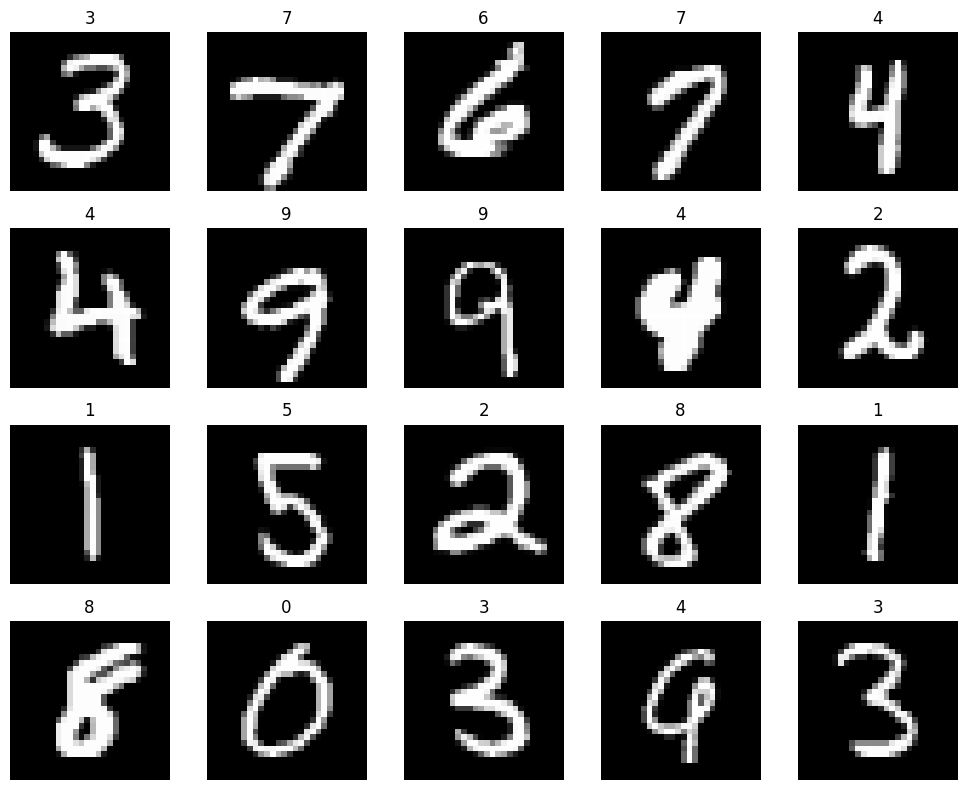

In [108]:

num_examples = 20
indices = np.random.choice(X_test.shape[0], num_examples, replace=False)


fig, axes = plt.subplots(4, 5, figsize=(10, 8))
axes = axes.flatten()

for i, idx in enumerate(indices):
    example = X_test[idx]
    image = example.reshape(28, 28)
    
    predicted = predict(example)
    axes[i].imshow(image, cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(str(predicted.argmax()))

plt.tight_layout()
plt.show()